# V44 (Cost-Sensitive + Cash Management): LQ45 AI Strategy

**Objective**: Implement realistic Cash Management where transaction costs are paid from the Cash Reserve, not by reducing portfolio value magically.

### Modification (Cash & Cost Logic):
1. **Minimum Cash Buffer**: Every portfolio allocation MUST keep at least **10% in Cash** at all times (`weights['CASH'] >= 0.1`).
2. **Cost Deduction**: Transaction fees are deducted directly from this Cash balance.
   - If Cash drops below 0 (impossible in reality, but for sim), the strategy goes bankrupt or sells assets to cover fees (simplified here as negative cash dragging performace correctly).

**Rationale**:
- This is more realistic. You cannot invest 100% because you need cash to pay for the buy/sell commisions.
- Keeping 10% dry powder also dampens volatility slightly.

### Comparisons:
1. **AI Hybrid V44 (Cost-Sensitive + 10% Cash)**.
2. **Markowitz Static (Baseline + 10% Cash)**.
3. **IHSG Proxy (Benchmark)**.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"Data Loaded: {len(data)} rows")


Data Loaded: 712 rows


In [2]:
# --- 2. Feature Engineering & Cost-Aware Model ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# Trend Signal (Standard MA50) for Hybrid Filter
trend_bullish = (market_price > ma50).astype(int)

# --- NEW TARGET DEFINITION ---
# Next day return
next_ret = market_return.shift(-1)

# Cost Threshold (e.g., 0.5% round-trip friction)
COST_THRESHOLD = -0.005 

# Target = 1 (Stay Invested) if drop is manageable (Return > -0.5%)
# Target = 0 (Exit) ONLY if drop is severe (Return <= -0.5%)
target = (next_ret > COST_THRESHOLD).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(1) # Default to Invested
trend_bullish = trend_bullish.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

# Train Cost-Sensitive Model
xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
ai_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)
test_trend = trend_bullish.loc[X_test.index]

opt_t = 0.50 # Standard threshold

print(f"[Strategy] Cost-Sensitive AI Trained. Target: Stay Invested if Return > {COST_THRESHOLD*100}%")


[Strategy] Cost-Sensitive AI Trained. Target: Stay Invested if Return > -0.5%


In [3]:
# --- 3. Simulation Logic (Cash Management) ---
# We will force 10% Cash allocation during Optimization

def optimize_markowitz(selected_returns, min_cash=0.1):
    if len(selected_returns.columns) == 0: return {'CASH': 1.0}
    
    # Standard Markowitz for 100% of the Equity Portion (which is 1 - min_cash)
    # Then we scale down weights
    
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    sigma += np.eye(len(sigma)) * 1e-4 
    try:
        res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                       [1./len(mu)]*len(mu), method='SLSQP', 
                       bounds=tuple((0, 1) for _ in range(len(mu))), 
                       constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
        
        if res.success:
            raw_weights = dict(zip(selected_returns.columns, res.x))
            # Scale down to (1 - min_cash)
            # Start with CASH = min_cash
            final_weights = {k: v * (1.0 - min_cash) for k, v in raw_weights.items()}
            final_weights['CASH'] = min_cash
            return final_weights
        else:
            return {'CASH': 1.0}
    except:
        return {'CASH': 1.0}

def run_simulation_cash_managed(strategy_type, test_dates, returns, ai_probs=None, trend_signal=None, threshold=0.5, fee=0.0025):
    val = 100.0
    history = [100.0]
    dates = [test_dates[0]]
    
    prev_weights = {'CASH': 1.0} # Start 100% Cash
    static_weights = None
    state_history = []
    
    # Logging list
    portfolio_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        weights = {}
        current_state = "Invested"

        if strategy_type == 'AI Hybrid V44 (CashManaged)':
            prob = ai_probs.loc[date]
            is_trend_up = trend_signal.loc[date] == 1
            
            is_risk_off = (prob < threshold) and (not is_trend_up)
            
            if is_risk_off:
                weights = {'CASH': 1.0}
                current_state = "Cash"
            else:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                # Force 10% Cash Buffer inside optimization
                weights = optimize_markowitz(window_rets[valid_assets], min_cash=0.10)
                current_state = "Invested"
                
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                valid_assets = window_rets.dropna(axis=1, how='any').columns
                # Markowitz Static also forced to keep 10% Cash
                static_weights = optimize_markowitz(window_rets[valid_assets], min_cash=0.10)
            weights = static_weights
            current_state = "Static"
        
        state_history.append(current_state)
        
        # Log Portfolio
        for asset, weight in weights.items():
            if weight > 0.001: 
                portfolio_log.append({
                    'Date': dates[-1].strftime('%Y-%m-%d'),
                    'Strategy': strategy_type,
                    'Ticker': asset,
                    'Weight': weight
                })
        
        # --- TRANSACTION COST LOGIC ---
        # Calculate Turnover
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        # Turnover on Equity portion only. Cash movements don't incur commission fees usually, 
        # but usually buying/selling stock does. 
        # For simplicity, we calculate turnover on all changes excluding self-cash adjustments if we consider cash free.
        # But standard model applies fee to total turnover volume.
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets if a != 'CASH')
        
        cost = val * turnover * fee
        
        # Deduct Cost from CASH portion of value
        # This effectively reduces the total Portfolio Value
        val -= cost
        
        next_date = test_dates[i+1]
        
        # Portfolio Return Calculation
        day_ret = 0.0
        for asset, weight in weights.items():
            if asset == 'CASH':
                # Cash earns 0% (or risk free rate, here 0 for simplicity)
                pass 
            else:
                r = returns.loc[next_date, asset]
                day_ret += weight * r
        
        # Apple Return
        val *= (1 + day_ret)
        
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history, 'State': state_history + [state_history[-1]]}, index=dates), portfolio_log


In [4]:
# --- 4. Models & Benchmark Execution ---

print("Running AI Hybrid V44 (Cash Managed)...")
hybrid_res_cost, hybrid_log = run_simulation_cash_managed('AI Hybrid V44 (CashManaged)', X_test.index, returns, ai_probs, test_trend, threshold=0.50)

print("Running Markowitz Static...")
static_res, static_log = run_simulation_cash_managed('Markowitz Static', X_test.index, returns)

print("Calculating IHSG Benchmark...")
ihsg_ret = market_return.loc[X_test.index]
ihsg_price = (1 + ihsg_ret).cumprod() * 100


Running AI Hybrid V44 (Cash Managed)...
Running Markowitz Static...
Calculating IHSG Benchmark...


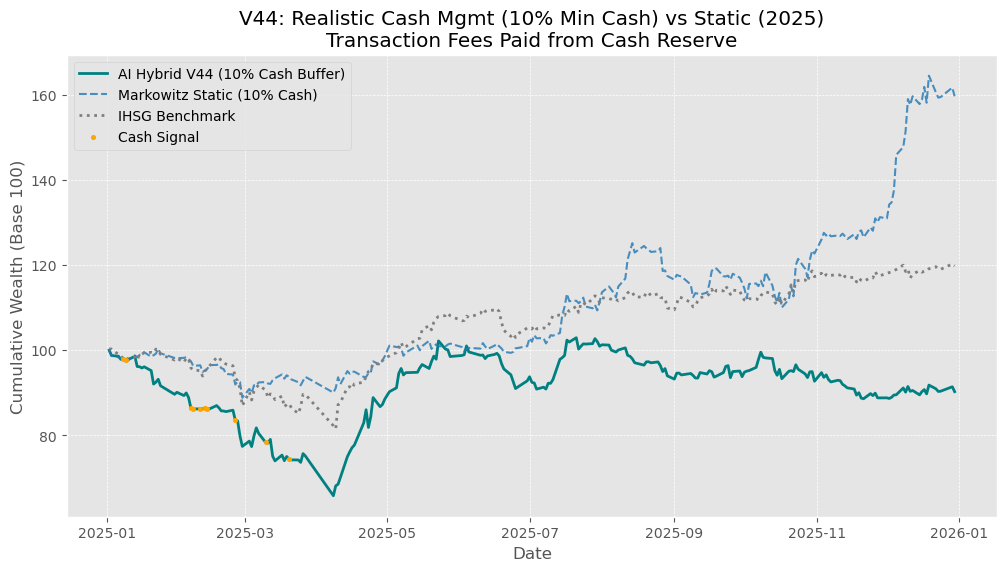

Total Days in Cash (100%): 10


In [5]:
# --- Visualization: Performance Comparison ---
plt.figure(figsize=(12, 6))
plt.plot(hybrid_res_cost['Portfolio_Value'], label=f'AI Hybrid V44 (10% Cash Buffer)', color='teal', linewidth=2)
plt.plot(static_res['Portfolio_Value'], label='Markowitz Static (10% Cash)', color='#1f77b4', linestyle='--', alpha=0.8)
plt.plot(ihsg_price, label='IHSG Benchmark', color='#7f7f7f', linestyle=':', linewidth=2)

# Highlight Cash Days
regime_switches = hybrid_res_cost[hybrid_res_cost['State'].str.contains('Cash')]
if not regime_switches.empty:
    plt.scatter(regime_switches.index, regime_switches['Portfolio_Value'], color='orange', s=10, label='Cash Signal', zorder=5)

plt.title(f'V44: Realistic Cash Mgmt (10% Min Cash) vs Static (2025)\nTransaction Fees Paid from Cash Reserve')
plt.ylabel('Cumulative Wealth (Base 100)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.savefig('v44_cash_managed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Stats
cash_days = hybrid_res_cost['State'].value_counts().get('Cash', 0)
print(f"Total Days in Cash (100%): {cash_days}")


In [6]:
# --- 5. Export Portfolio to Excel ---
# Combine logs
full_log = hybrid_log + static_log
log_df = pd.DataFrame(full_log)

output_excel = 'v20_portfolio_with_visibility_2025.xlsx'

with pd.ExcelWriter(output_excel) as writer:
    # Sheet 1: Hybrid Strategy Log
    hybrid_df = log_df[log_df['Strategy'] == 'AI Hybrid V44 (CashManaged)']
    if not hybrid_df.empty:
        hybrid_pivot = hybrid_df.pivot(index='Date', columns='Ticker', values='Weight').fillna(0)
        hybrid_pivot.to_excel(writer, sheet_name='AI Hybrid Portfolio')
    
    # Sheet 2: Static Strategy Log
    static_df = log_df[log_df['Strategy'] == 'Markowitz Static']
    if not static_df.empty:
        static_pivot = static_df.pivot(index='Date', columns='Ticker', values='Weight').fillna(0)
        static_pivot.to_excel(writer, sheet_name='Markowitz Static Portfolio')

    # Sheet 3: Raw Data
    log_df.to_excel(writer, sheet_name='Raw Log', index=False)

print(f"Portfolio log exported to: {output_excel}")


Portfolio log exported to: v20_portfolio_with_visibility_2025.xlsx
